In [2]:
import glob
import os
from astropy.io import fits

fits_files = glob.glob('data/*.fits')
hdul = fits.open(fits_files[1])

In [3]:
hdul[1].data

FITS_rec([([3781.75, 3781.76, 3781.77, ..., 6913.57, 6913.58, 6913.59], [  328.03732 ,   149.94778 ,   388.7066  , ...,  7320.707   ,  6347.75    ,  5253.9106  ], [nan, nan, nan, ..., nan, nan, nan])],
         dtype=(numpy.record, [('WAVE', '>f8', (313185,)), ('FLUX', '>f4', (313185,)), ('ERR', '>f4', (313185,))]))

In [4]:
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

In [5]:
len(hdul[1].data['FLUX'][0])

313185

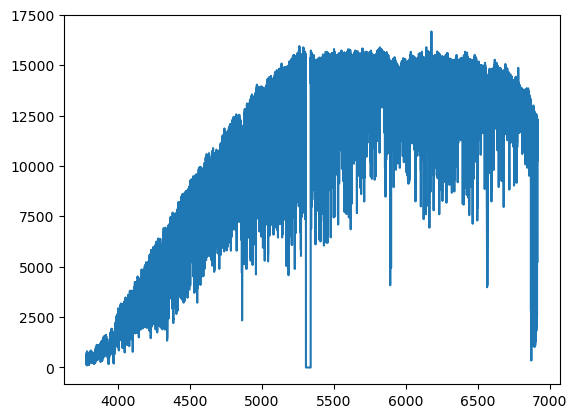

In [6]:
plt.plot(hdul[1].data['WAVE'][0], hdul[1].data['FLUX'][0])

In [7]:
import numpy as np

for i, fits_file in enumerate(fits_files):
    hdul = fits.open(fits_file)
    # Stack wavelength and flux arrays as columns and save to CSV (only first spectrum)
    data_to_save = np.column_stack((hdul[1].data['WAVE'][0], hdul[1].data['FLUX'][0], hdul[1].data['ERR'][0]))
    np.savetxt(f"raw_data/spectrum{i}.txt", data_to_save, delimiter=" ",comments='')

In [14]:
hdul[0].header

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                    8 / number of bits per data pixel                  
NAXIS   =                    0 / number of data axes                            
EXTEND  =                    T / FITS dataset may contain extensions            
DATASUM = '0       '           / data unit checksum updated 2014-09-23T20:42:05 
COMMENT FITS (Flexible Image Transport System) format is defined in 'Astronomy  
COMMENT and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H   
DATE    = '2014-08-07T10:33:04.692' / UT date when this file was written        
INSTRUME= 'HARPS   '           / Instrument used.                               
RA      =            48.667221 / 03:14:40.1 RA (J2000) pointing (deg)           
DEC     =            -35.55646 / -35:33:23.2 DEC (J2000) pointing (deg)         
EQUINOX =                2000. / Standard FK5 (years)                           
RADECSYS= 'FK5     '        

In [15]:
hdul[0].header['HIERARCH ESO DRS BJD']

2456876.93959495

In [16]:
import numpy as np
len(hdul[1].data['WAVE'][0][np.isclose(hdul[1].data['FLUX'][0], 0)])

3295

In [17]:
from tqdm import tqdm
wavelengths = []
fluxes = []
errors = []
source_files = []

snrs = []
mjd_starts = []
mjd_ends = []
exptimes = []
bjds = []

for f in tqdm(fits_files):
    try:
        hdul = fits.open(f)
        wvs = hdul[1].data['WAVE'][0]
        flx = hdul[1].data['FLUX'][0]
        err = hdul[1].data['ERR'][0]
        snr = hdul[0].header['SNR']
        mjd_start = hdul[0].header['MJD-OBS']
        mjd_end = hdul[0].header['MJD-END']
        exptime = hdul[0].header['EXPTIME']
        bjd = hdul[0].header['HIERARCH ESO DRS BJD']
    except:
        continue
    wavelengths.append(wvs)
    fluxes.append(flx)
    errors.append(err)
    source_files.append(os.path.basename(f))
    snrs.append(snr)
    mjd_starts.append(mjd_start)
    mjd_ends.append(mjd_end)
    exptimes.append(exptime)
    bjds.append(bjd)

100%|██████████| 22/22 [00:00<00:00, 78.56it/s]


In [18]:
# Find the maximum length
maxlen = max([len(wvs) for wvs in wavelengths])

# Pad all arrays to the same size
wavelengths_padded = np.array([np.pad(wvs, (0, maxlen - len(wvs)), constant_values=np.nan) for wvs in wavelengths])
fluxes_padded = np.array([np.pad(flx, (0, maxlen - len(flx)), constant_values=np.nan) for flx in fluxes])
errors_padded = np.array([np.pad(err, (0, maxlen - len(err)), constant_values=np.nan) for err in errors])

In [20]:
import zarr
import numpy as np
from zarr.codecs import BloscCodec

# Open Zarr v3 group
root = zarr.open_group(
    "harps_data.zarr",
    mode="w",
    zarr_version=3
)

# Zarr v3 native codec (NOT numcodecs.Blosc)
compressor = BloscCodec(cname="zstd", clevel=3)

# Create arrays
root.create_array(
    "wavelengths",
    data=wavelengths_padded,
    fill_value=np.nan,
    compressors=[compressor]
)

root.create_array(
    "fluxes",
    data=fluxes_padded,
    fill_value=np.nan,
    compressors=[compressor]
)

root.create_array(
    "errors",
    data=errors_padded,
    fill_value=np.nan,
    compressors=[compressor]
)

root.create_array("snrs", data=np.asarray(snrs))
root.create_array("mjd_starts", data=np.asarray(mjd_starts))
root.create_array("mjd_ends", data=np.asarray(mjd_ends))
root.create_array("exptimes", data=np.asarray(exptimes))
root.create_array("bjds", data=np.asarray(bjds))
root.attrs['raw_source_files'] = source_files

print("Saved data to harps_data.zarr (Zarr v3)")

Saved data to harps_data.zarr (Zarr v3)


In [ ]:
# Validate that every raw wavelength row was written instead of falling back to the fill value.
written = zarr.open_group('harps_data.zarr', mode='r')
bad_rows = []
for i in range(written['wavelengths'].shape[0]):
    wave = written['wavelengths'][i, :]
    if not np.isfinite(wave).any():
        bad_rows.append(i)

if bad_rows:
    raise RuntimeError(f'Wavelength rows missing from Zarr write: {bad_rows}')

print('Validated raw wavelength write for all rows.')